# GeoBCP Tutorial — *uncertainty about the uncertainty*

Conformal prediction gives each location a prediction interval. But that interval is itself **estimated** — from whatever calibration data happens to lie nearby. In data-sparse regions it rests on a handful of points, yet on a map it looks just as authoritative as an interval backed by hundreds.

**GeoBCP** (Geographical Bayesian Conformal Prediction) puts a *posterior* over each location's interval, so you can read off **how much to trust it**: the posterior spread of the threshold, the local effective sample size, and the probability the interval is uninformative.

This notebook builds **GeoCP** (the interval) and then **GeoBCP** (the interval **+ its reliability**) on the Seattle house-price sample, and maps where the intervals can be trusted.

> Install: `pip install "geoconformal>=0.3.0"`. Run this notebook from the `example/` folder.

## 1. Data & model

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

from geoconformal import GeoConformalRegressor

# Seattle house-price sample: 8 features, UTM coordinates, log price.
df = pd.read_csv("seattle_sample_3k.csv")
FEATURES = ["bathrooms", "sqft_living", "sqft_lot", "grade",
            "condition", "waterfront", "view", "age"]
X = df[FEATURES].to_numpy(float)
y = df["log_price"].to_numpy(float)
coord = df[["UTM_X", "UTM_Y"]].to_numpy(float)
print(f"{len(df)} rows, {len(FEATURES)} features")

3000 rows, 8 features


We split into **train** (fits the model), **calibration** (geoconformal measures residuals here), and **test**. Coordinates are standardized on the train pool so the kernel `bandwidth` is in standard-deviation units rather than metres.

In [2]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(y))
tr, ca, te = perm[:2000], perm[2000:2400], perm[2400:2800]

# Standardize coordinates (fit on train) -> bandwidth is in std-dev units.
cmu, csd = coord[tr].mean(0), coord[tr].std(0)
cz = (coord - cmu) / csd

model = RandomForestRegressor(n_estimators=200, random_state=0).fit(X[tr], y[tr])
print("train / calib / test:", len(tr), len(ca), len(te))

train / calib / test: 2000 400 400


## 2. GeoCP — the interval (point estimate)

First the ordinary GeoCP interval: weight calibration residuals by geographic distance to each test point, then take a weighted quantile. One interval per location.

In [3]:
reg = GeoConformalRegressor(
    predict_f=model.predict,
    x_calib=X[ca], y_calib=y[ca], coord_calib=cz[ca],
    bandwidth=0.5, miscoverage_level=0.1,   # 90% target coverage
)
pt = reg.geo_conformalize(X[te], y[te], cz[te])
print(f"GeoCP  coverage = {pt.coverage:.3f}   mean interval width = {pt.mean_width_finite:.3f}")

GeoCP  coverage = 0.945   mean interval width = 0.491


## 3. GeoBCP — a posterior over the interval

Now turn on the Bayesian posterior. Instead of a single threshold per location, GeoBCP draws a *posterior* over it (a weighted-Dirichlet model whose concentration is the local effective sample size) and reports an HPD interval at confidence `beta`, plus three diagnostics:

- **`n_eff`** — Kish effective sample size: how many calibration points effectively support this location.
- **`posterior_std`** — spread of the threshold posterior: the *uncertainty about the uncertainty*.
- **`prob_infinite`** — posterior probability the interval is uninformative (`+inf`).

Just pass `bayesian=True`:

In [4]:
bcp = reg.geo_conformalize(
    X[te], y[te], cz[te],
    bayesian=True, beta=0.9, num_mc=1000,
)
print(f"GeoBCP coverage                    = {bcp.coverage:.3f}")
print(f"mean effective sample size (n_eff) = {bcp.mean_n_eff:.1f}")
print(f"mean posterior std of threshold    = {bcp.mean_sigma_post:.4f}")
print(f"fraction abstaining (+inf)         = {bcp.frac_infinite:.2f}")

GeoBCP coverage                    = 0.963
mean effective sample size (n_eff) = 84.5
mean posterior std of threshold    = 0.0323
fraction abstaining (+inf)         = 0.06


## 4. Same width, different reliability

The whole point: two locations can get a similar interval width for very different reasons. A location with **few** nearby calibration points (low `n_eff`) has a **wider, less certain** threshold posterior (high `posterior_std`) — its interval is less trustworthy, even if its width looks ordinary.

The scatter below shows that relationship across the test set: less local support → more meta-uncertainty.

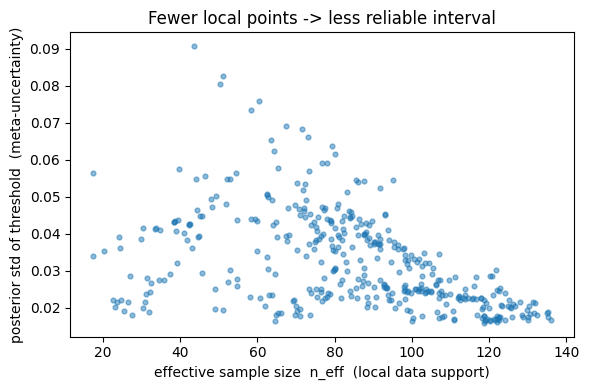

In [5]:
finite = np.isfinite(bcp.posterior_std)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(bcp.n_eff[finite], bcp.posterior_std[finite], s=12, alpha=0.5)
ax.set_xlabel("effective sample size  n_eff  (local data support)")
ax.set_ylabel("posterior std of threshold  (meta-uncertainty)")
ax.set_title("Fewer local points -> less reliable interval")
fig.tight_layout()
plt.show()

## 5. Map it — where can you trust the intervals?

Three maps over the test locations: the **interval width** (level-1 uncertainty), the **posterior std** (level-2: uncertainty about that width), and the **effective sample size** (local support). Read them together — a wide interval with *low* posterior std is genuinely uncertain but trustworthy; any interval with *high* posterior std / *low* `n_eff` should be treated with caution.

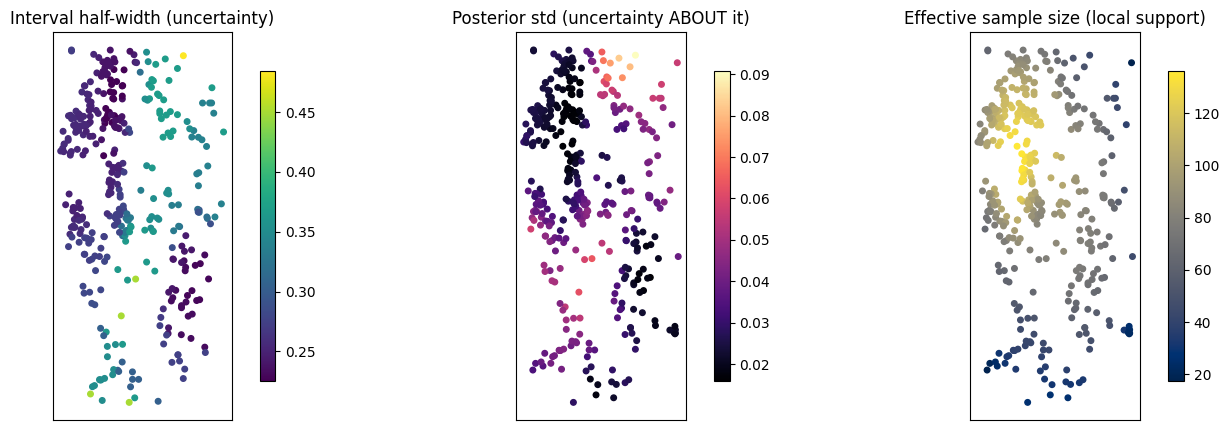

In [6]:
xt, yt = coord[te, 0], coord[te, 1]   # original UTM coords for plotting
panels = [
    (bcp.uncertainty,   "Interval half-width (uncertainty)", "viridis"),
    (bcp.posterior_std, "Posterior std (uncertainty ABOUT it)", "magma"),
    (bcp.n_eff,         "Effective sample size (local support)", "cividis"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (vals, title, cmap) in zip(axes, panels):
    v = np.asarray(vals, float)
    m = np.isfinite(v)
    sc = ax.scatter(xt[m], yt[m], c=v[m], s=16, cmap=cmap)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 6. Per-location reliability table

Sorted by `posterior_std` — the least reliable locations first.

In [7]:
table = pd.DataFrame({
    "UTM_X": coord[te, 0], "UTM_Y": coord[te, 1],
    "pred": bcp.pred_value,
    "half_width": bcp.uncertainty,
    "posterior_std": bcp.posterior_std,
    "n_eff": bcp.n_eff,
    "prob_infinite": bcp.prob_infinite,
})
table.sort_values("posterior_std", ascending=False).head(8).round(3)

,UTM_X,UTM_Y,pred,half_width,posterior_std,n_eff,prob_infinite
260,562789.969,5290910.486,5.563,0.484,0.091,43.587,0.059
316,560097.288,5290426.225,5.378,0.367,0.083,51.016,0.025
384,561911.002,5289011.436,5.700,0.367,0.080,50.353,0.021
143,558681.530,5289622.548,5.515,0.367,0.076,60.509,0.013
138,560655.281,5287230.855,5.550,0.367,0.073,58.298,0.006
303,557553.288,5290022.502,5.524,0.353,0.069,67.443,0.009
363,558331.386,5287173.690,5.629,0.367,0.068,71.635,0.005
29,558104.567,5287360.372,5.458,0.367,0.066,72.990,0.005


## Where GeoBCP fits

GeoBCP is **one axis** of `geoconformal`, orthogonal to the weighting:

- **Weighting (how uncertainty is localized):** `GeoCP` (geographic) or `GeoSIMCP` (geographic + feature similarity).
- **Estimate (this notebook's axis):** a point interval, or **GeoBCP** — the interval *plus its reliability*.

Here we used GeoBCP with geographic (GeoCP) weighting. To combine it with **GeoSIMCP** weighting, use the engine directly with `joint_geo_feature_weights` and call `bayesian_conformalize`. For small / sparse calibration sets, add `include_test_atom=True` for finite-sample-valid coverage (the interval becomes `+inf` where local data can't certify the level).

See the project README's *Choosing a method* guide for the full picture.